In [2]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
from sklearn.preprocessing import StandardScaler
from src.utils.cox_models import *
scipy.integrate.simps = scipy.integrate.simpson
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.util import Surv
from itertools import product
import torch

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
pp = Preprocessor()

In [4]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [7]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")
df_merged = TorchPreprocessing(clean_mRNA_df,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818
Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533


array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [8]:
zero_reduced_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")
print(f"Samples: {zero_reduced_df.shape[0]}, Genes: {zero_reduced_df.shape[1]}")
zero_reduced_df =  zero_reduced_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

Genes before Treshold: 18533
count    18533.000000
mean        31.338261
std         83.872808
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        415.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [9]:
results_df

,HER2-enriched,Luminal A,Luminal B,TNBC,AveExpr,F,pvalue,adj_pvalue
YTHDF1,10.879097,10.704586,10.782180,10.716942,10.726453,69230.027576,0.000000e+00,0.000000e+00
STRADA,9.487686,9.188342,9.375162,8.935217,9.189309,40043.610021,0.000000e+00,0.000000e+00
PIK3R6,4.953432,5.001262,5.058186,5.178365,5.037032,4016.626570,0.000000e+00,0.000000e+00
SAMD9,9.454183,9.385430,9.352988,9.353712,9.378219,8472.898002,0.000000e+00,0.000000e+00
YME1L1,12.087980,11.915021,11.968255,12.079383,11.957913,100013.934220,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...
TMEM229A,0.349584,0.207897,0.218256,0.103054,0.198622,12.900652,1.670292e-10,1.670652e-10
PAGE2,0.285851,0.312058,0.459990,0.754457,0.406439,12.836736,1.889000e-10,1.889306e-10
SLC28A2,0.355432,0.277010,0.242954,0.086340,0.243943,12.577395,3.111464e-10,3.111800e-10
FMR1NB,0.084961,0.267415,0.215001,0.499620,0.289179,11.949205,1.040456e-09,1.040512e-09


In [60]:
N_GENES = 100
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES].tolist()

torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma

X_scaled, durations, events, scaler = torch_preprocessing.get_data_set(60)

Genes before Treshold: 103
count    103.000000
mean       1.330097
std        6.002268
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       42.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 103


In [61]:
X_scaled.shape

(519, 100)

In [62]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [63]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

In [64]:
train_X.shape

torch.Size([415, 100])

Grid Search for the best Model

In [65]:
from itertools import product

param_grid = {
    "num_nodes": [[32,16], [32,32], [64,32]],
    "dropout": [0.0, 0.2, 0.4],
    "batch_norm": [True, False],
    "lr": [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size": [64 ,128, 256],
}

grid = list(product(
    param_grid["num_nodes"],
    param_grid["dropout"],
    param_grid["batch_norm"],
    param_grid["lr"],
    param_grid["weight_decay"],
    param_grid["batch_size"],
))

In [ ]:
in_features = train_X.shape[1]
output_bias = False

best_score = -1
best_params = None

train_X = np.array(train_X)
train_durations = np.array(train_durations)
train_events = np.array(train_events).astype(bool)

val_X = np.array(val_X)
val_durations = np.array(val_durations)
val_events = np.array(val_events).astype(bool)

for num_nodes,dp,bn, lr, wd, batch_size  in grid:
    net = tt.torchtuples.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=num_nodes,
        out_features=1,
        dropout=dp,
        output_bias=output_bias,
        batch_norm=bn,
        )
    
    model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=wd))
    
    model.optimizer.set_lr(lr)
    model.fit(
                input=train_X,
                target=(train_durations, train_events),
                epochs=100,
                verbose=False,
                val_data=(val_X, (val_durations, val_events)),
                val_batch_size=batch_size
            )
    
    model.net.eval()
    model.compute_baseline_hazards()
    surv = model.predict_surv_df(val_X)

    ev = EvalSurv(surv, val_durations, val_events)
    c_index = ev.concordance_td()
    if c_index > best_score:
                best_score = c_index
                best_params = (num_nodes, dp, bn, lr, wd, batch_size)

    

print(best_params, best_score)


([32, 32], 0.4, True, 0.0005, 0, 256) 0.9649122807017544


Training the Model

In [66]:
in_features = train_X.shape[1]
output_bias = False

num_nodes = [32, 32]
out_features = 1
dropout = 0.4
batch_norm = True
lr = 0.005 
weight_decay = 0
batch_size = 256



net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=num_nodes, 
    out_features=out_features, 
    batch_norm=batch_norm,
    dropout=dropout,
    output_bias=output_bias
)
model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=weight_decay))


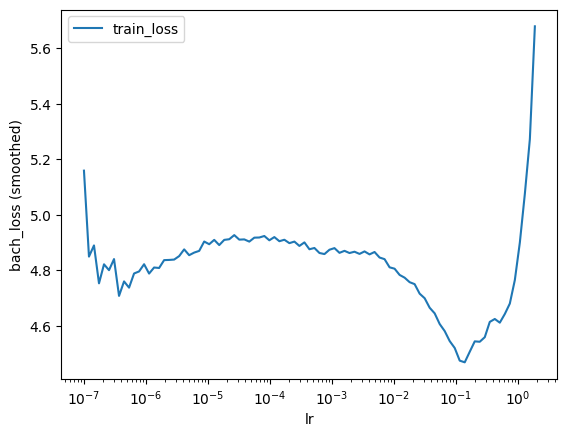

In [67]:
batch_size = batch_size
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=20)

_ = lrfinder.plot()

In [68]:
train_durations.shape

torch.Size([415])

In [69]:
model.optimizer.set_lr(lr)


In [70]:
epochs = 100
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=10)]
verbose = True

In [71]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.9129,	val_loss: 3.3595
1:	[0s / 0s],		train_loss: 4.7076,	val_loss: 3.3188
2:	[0s / 0s],		train_loss: 4.5193,	val_loss: 3.2749
3:	[0s / 0s],		train_loss: 4.4597,	val_loss: 3.2110
4:	[0s / 0s],		train_loss: 4.5046,	val_loss: 3.1378
5:	[0s / 0s],		train_loss: 4.3460,	val_loss: 3.0673
6:	[0s / 0s],		train_loss: 4.3217,	val_loss: 2.9981
7:	[0s / 0s],		train_loss: 4.0725,	val_loss: 2.9330
8:	[0s / 0s],		train_loss: 3.9775,	val_loss: 2.8665
9:	[0s / 0s],		train_loss: 4.0160,	val_loss: 2.8036
10:	[0s / 0s],		train_loss: 3.9492,	val_loss: 2.7479
11:	[0s / 0s],		train_loss: 3.8301,	val_loss: 2.6998
12:	[0s / 0s],		train_loss: 3.8293,	val_loss: 2.6610
13:	[0s / 0s],		train_loss: 4.0212,	val_loss: 2.6465
14:	[0s / 0s],		train_loss: 3.6496,	val_loss: 2.6494
15:	[0s / 0s],		train_loss: 3.5061,	val_loss: 2.6537
16:	[0s / 0s],		train_loss: 3.7216,	val_loss: 2.6511
17:	[0s / 0s],		train_loss: 3.4895,	val_loss: 2.6480
18:	[0s / 0s],		train_loss: 3.4737,	val_loss: 2.6347
19:

torch.Size([52, 100])

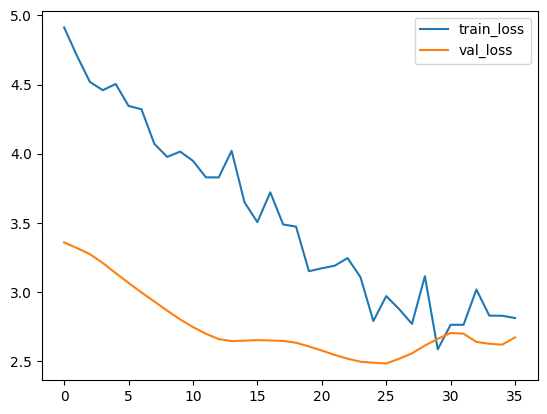

In [72]:
_ = log.plot()
val_X.shape

Log Likehood (The Loss)

In [73]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()


-2.4848638

In [74]:
_ = model.compute_baseline_hazards()

In [75]:
surv = model.predict_surv_df(input=test_X)

In [76]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(275, 52)

Kaplan Meier

In [77]:
risk_nn = model.net(test_X).flatten()

list_risk = []
for i in risk_nn:
    list_risk.append(i.item())



For this group the risk High

For the time 0 the risk group is 26
For the time 12 the risk group is 20
For the time 24 the risk group is 11
For the time 36 the risk group is 5
For the time 48 the risk group is 4
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 26
For the time 12 the risk group is 21
For the time 24 the risk group is 14
For the time 36 the risk group is 10
For the time 48 the risk group is 5
For the time 60 the risk group is 0


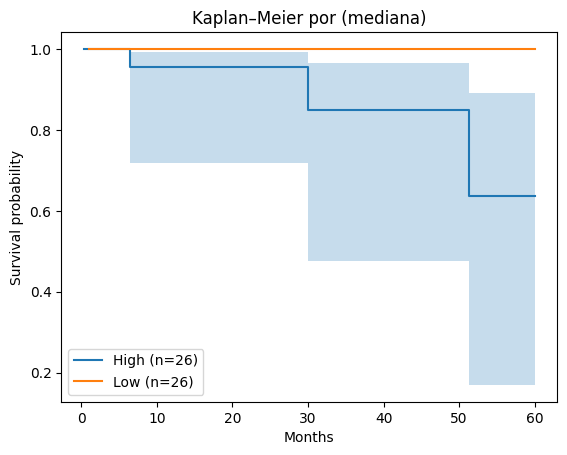

In [78]:
df = pd.DataFrame()

thr = np.median(list_risk)
df["group"] = np.where(risk_nn > thr, "High", "Low")
df["duration"] = test_durations
df["event"] = test_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

Log Rank of the Model

In [79]:

time_all = df["duration"].to_numpy(dtype=float)
event_all = df["event"].to_numpy(dtype=bool)
event_60_months = event_all.copy()
event_60_months[time_all > 60] = False
time_60_months = np.minimum(time_all, 60)

y = Surv.from_arrays(event_60_months, time_60_months)
chisq, pvalue = compare_survival(y, df["group"].to_numpy())
print(f"Log-rank: chi2={chisq:.3f}, p={pvalue:.4g}")


Log-rank: chi2=3.271, p=0.07052


Prediction of survival of the Patients

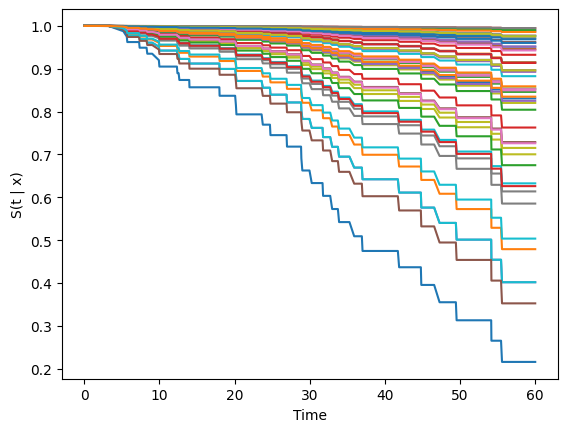

In [80]:
surv.iloc[:, :].plot()
plt.ylabel('S(t | x)')
plt.legend().set_visible(False)
_ = plt.xlabel("Time")

In [81]:
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [82]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


Concordance of the Model

In [83]:
print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.9305555555555556


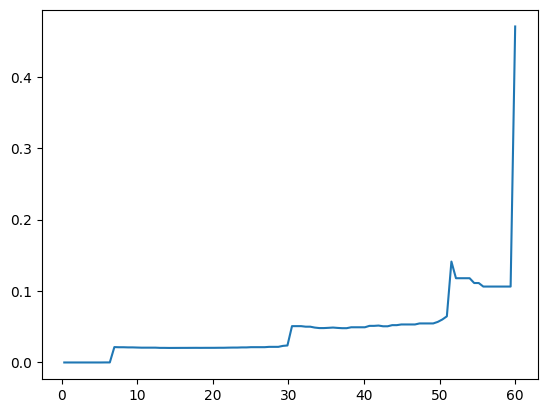

In [84]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [85]:
ev.integrated_brier_score(time_grid=time_grid)

0.04476398822691481

In [86]:
ev.integrated_nbll(time_grid)

0.1499054851077879